In [2]:
# imports
import json
import pandas as pd

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns

In [10]:
path = "fly_bubble_data_20241024/test_annotations.json"
with open(path) as f:
    coco_data = json.load(f)
    
    print(coco_data.keys())
    
data = pd.DataFrame.from_records(coco_data["annotations"], columns=["id", "mov", "category_id", "image_id", "keypoints", "behavior"])

dict_keys(['info', 'annotations', 'images', 'categories'])


In [11]:
data

,id,mov,category_id,image_id,keypoints,behavior
0,0,18,0,0,"[93.71441592709778, 73.37859731904382, 2, 101....",4
1,1,20,0,1,"[96.93077609407851, 85.12687331793063, 2, 103....",4
2,2,14,0,2,"[95.03162326581105, 68.17802383898213, 2, 102....",1
3,3,8,0,3,"[94.8884896125403, 73.92241918534984, 2, 101.8...",1
4,4,2,0,4,"[95.21122760260039, 65.75644306784727, 2, 103....",2
...,...,...,...,...,...,...
2488,2488,9,0,2488,"[95.13745973293004, 67.1010124128527, 2, 102.8...",1
2489,2489,7,0,2489,"[95.60267170939483, 76.71107718075062, 2, 101....",1
2490,2490,14,0,2490,"[95.83287819685916, 73.86291720415727, 2, 102....",2
2491,2491,3,0,2491,"[95.61941021121572, 74.36439261483213, 2, 102....",2


<Axes: >

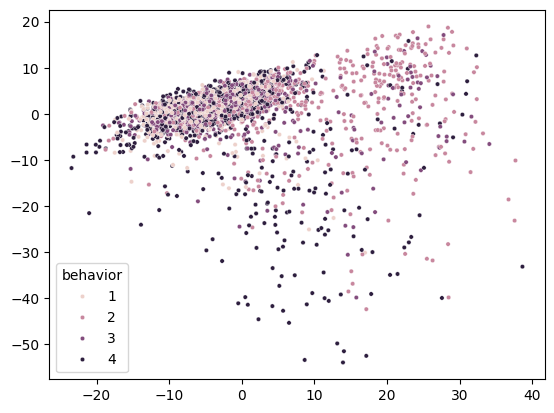

In [12]:
# normal pca embeddings
embedder = PCA(
    n_components=2
)

# embedder = TSNE(
#     n_components=2,
#     init="pca",
#     max_iter=1000,
#     random_state=1,
# )

X = np.stack(data["keypoints"])[:,::3]
X_new = embedder.fit_transform(X)

sns.scatterplot(x = X_new[:,0], y = X_new[:,1], hue=data["behavior"], s = 10)

<Axes: >

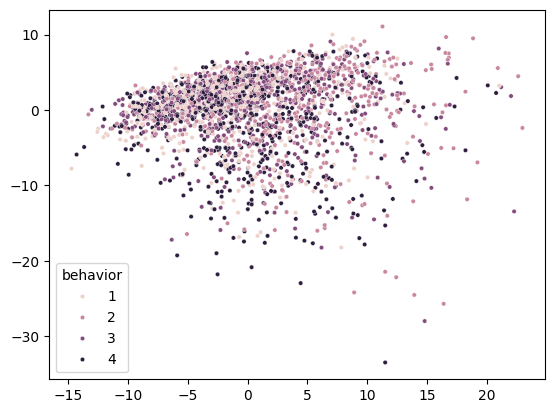

In [13]:
X = np.stack(data["keypoints"])[:,::3]
X_windows = sliding_window_view(X, 3, axis=0).mean(axis=-1)
X_new = embedder.fit_transform(X_windows)

sns.scatterplot(x = X_new[:,0], y = X_new[:,1], hue=data["behavior"][:2491], s = 10)